# Audio Preprocessing and Dataset Preparation

## Introduction

After exploring the datasets and analyzing their audio properties, the next step is to prepare the data for Machine Learning and Deep Learning experiments.

Raw audio recordings cannot be used directly because music datasets often contain differences in:

- sample rate,
- duration,
- number of channels,
- loudness,
- and recording characteristics.

Therefore, preprocessing is required to create a consistent input representation across all experiments.

This notebook focuses on preparing both datasets:

- GTZAN Dataset (training and validation)
- FMA Medium Dataset (external evaluation)

The preprocessing pipeline is designed to preserve relevant musical information while standardizing technical properties of the audio.

---

# Objectives

The main goals of this notebook are:

- prepare audio data for feature extraction,
- standardize audio properties across datasets,
- create reproducible dataset splits,
- and establish a consistent preprocessing pipeline.

---

# Planned Preprocessing Steps

The following preprocessing operations will be applied:

1. Dataset loading and validation

2. Audio resampling
   - convert recordings to a unified sample rate

3. Channel standardization
   - convert audio into mono representation

4. Duration standardization
   - crop recordings to fixed length and exclude recordings shorter than the target duration

5. Signal normalization
   - carefully normalize inputs while preserving musical dynamics

6. Dataset splitting
   - create training and validation subsets for GTZAN

7. External evaluation preparation
   - select compatible genres from FMA Medium

8. Save processed metadata
   - prepare inputs for feature extraction

---

# Design Decisions

Several preprocessing decisions are intentionally made to preserve the validity of later experiments.

### Mono Conversion

Audio signals will be converted to mono in order to:

- reduce computational complexity,
- simplify model inputs,
- improve reproducibility.

This removes stereo information and is considered a limitation of the project.

### Dynamic Range Preservation

Amplitude preprocessing will be applied carefully.

No aggressive dynamic compression will be used because musical dynamics may contain genre-related information, especially for:

- classical music,
- jazz,
- acoustic recordings.

### External Evaluation

FMA Medium will not participate in training.

It will remain unseen during model development and will be used only for final external testing.

---

# Expected Output

The output of this notebook will be standardized audio metadata and prepared datasets for feature extraction.

The next notebook will focus on:

- MFCC extraction,
- Mel Spectrogram generation,
- and creation of input representations for Machine Learning and Deep Learning models.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import librosa

from sklearn.model_selection import train_test_split

from src.data.preprocessing import (
    preprocess_audio
)

from src.utils.config import *

In [2]:
from src.data.dataset_loader import (

    get_dataset_paths,

    load_gtzan_metadata,

    load_fma_tracks,

    select_fma_medium_shared_genres,
)

In [3]:
paths = get_dataset_paths()

gtzan_metadata = load_gtzan_metadata(
    paths["gtzan"]
)

tracks = load_fma_tracks(
    paths["fma_metadata"]
)

gtzan_metadata.head()

,dataset,filepath,original_genre,label
0,gtzan,C:\Softuni ML course\Project\music-genre-class...,blues,blues
1,gtzan,C:\Softuni ML course\Project\music-genre-class...,blues,blues
2,gtzan,C:\Softuni ML course\Project\music-genre-class...,blues,blues
3,gtzan,C:\Softuni ML course\Project\music-genre-class...,blues,blues
4,gtzan,C:\Softuni ML course\Project\music-genre-class...,blues,blues


# Preprocessing Configuration

The preprocessing pipeline is controlled through a set of configuration parameters.

These parameters are selected to balance:

- computational efficiency,
- preservation of musical information,
- reproducibility across experiments,
- and compatibility between datasets.

The selected values are explained below.

### Sample Rate

A sampling rate of **22050 Hz** is used.

This value reduces computational cost while preserving the frequency range necessary for music genre recognition.

According to the Nyquist principle, this allows representation of frequencies up to approximately **11 kHz**, which is sufficient for most genre-related spectral characteristics.

### Target Duration

Audio recordings are standardized to **28 seconds**.

This value was selected based on the characteristics of the GTZAN dataset, where recordings are approximately **30 seconds** long.

Tracks shorter than this threshold are excluded.

A fixed duration ensures consistent input dimensions for later Machine Learning and Deep Learning models.

### Mono Conversion

Audio is converted to mono.

This reduces dimensionality and removes dependence on stereo characteristics while preserving most spectral and rhythmic information.

### Cropping Strategy

Center cropping is selected.

This avoids bias toward only the beginning of recordings and increases the probability of capturing representative musical content.

### Normalization

No amplitude normalization is applied.

Musical dynamics may contain genre-related information and therefore aggressive loudness standardization is intentionally avoided.

In [4]:
# ================================
# Load Configuration
# ================================

print(
    "Configuration loaded."
)

print()

print(
    f"Sample Rate: {SAMPLE_RATE}"
)

print(
    f"Target Duration: {TARGET_DURATION}"
)

print(
    f"Mono: {MONO}"
)

print(
    f"Crop Mode: {CROP_MODE}"
)

print(
    f"Normalization: {NORMALIZATION}"
)

Configuration loaded.

Sample Rate: 22050
Target Duration: 28
Mono: True
Crop Mode: center
Normalization: None


In [5]:
# ================================
# Preprocess Example Audio
# ================================

example_file = (
    gtzan_metadata
    .iloc[0]
    ["filepath"]
)

print(
    example_file
)

y, sr = preprocess_audio(
    filepath=example_file,
    sample_rate=SAMPLE_RATE,
    mono=MONO,
    duration=TARGET_DURATION,
    crop_mode=CROP_MODE,
    normalization=NORMALIZATION
)

print()

print(
    "Sample Rate:",
    sr
)

print(
    "Duration:",
    len(y)/sr
)

print(
    "Shape:",
    y.shape
)

C:\Softuni ML course\Project\music-genre-classification\data\raw\gtzan\genres\blues\blues.00000.au

Sample Rate: 22050
Duration: 28.0
Shape: (617400,)


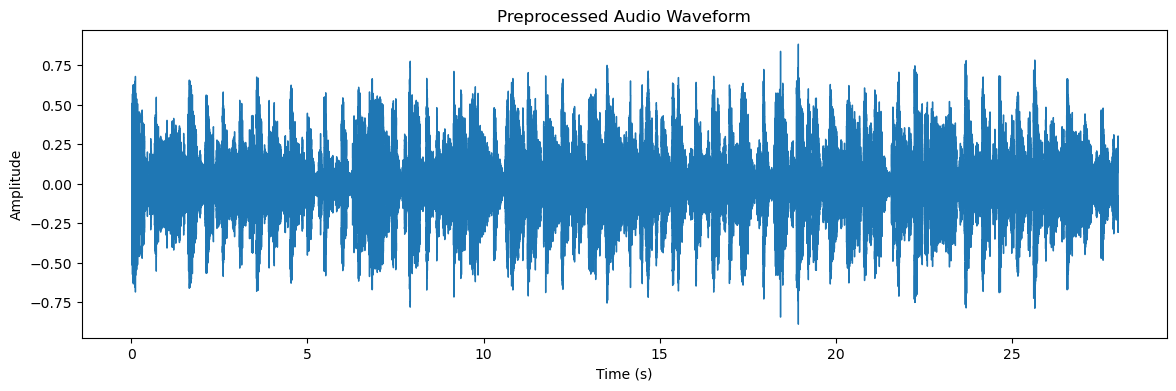

In [6]:
# ================================
# Visualize Preprocessed Audio
# ================================

plt.figure(figsize=(14, 4))

librosa.display.waveshow(
    y,
    sr=sr
)

plt.title("Preprocessed Audio Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

plt.show()

# Preprocessing Validation

The preprocessing pipeline was validated using a sample audio recording.

After preprocessing:

- the audio was resampled to the target sample rate,
- converted to mono,
- standardized to a fixed duration of 28 seconds,
- and preserved without aggressive amplitude normalization.

The waveform remains visually consistent and does not exhibit obvious truncation or silent padding artifacts.

This confirms that the preprocessing pipeline produces standardized inputs suitable for later feature extraction and model training.

The next step is to apply the preprocessing strategy to the complete GTZAN dataset and prepare the final training and validation splits.

# GTZAN Dataset Filtering and Preparation

Before creating training and validation datasets, preprocessing constraints are applied to all recordings.

Only recordings satisfying the duration requirements are retained.

This step guarantees that later feature extraction receives standardized inputs and avoids inconsistencies caused by variable recording lengths.

In [7]:
# ================================
# Filter GTZAN by Duration
# ================================

valid_rows = []

for _, row in gtzan_metadata.iterrows():

    try:

        duration = librosa.get_duration(
            path=row["filepath"]
        )

        if duration >= TARGET_DURATION:

            valid_rows.append(
                row
            )

    except Exception:

        continue


gtzan_filtered = pd.DataFrame(
    valid_rows
)

print(
    "Original:",
    len(gtzan_metadata)
)

print(
    "Remaining:",
    len(gtzan_filtered)
)

Original: 1000
Remaining: 1000


In [8]:
gtzan_filtered.head()

,dataset,filepath,original_genre,label
0,gtzan,C:\Softuni ML course\Project\music-genre-class...,blues,blues
1,gtzan,C:\Softuni ML course\Project\music-genre-class...,blues,blues
2,gtzan,C:\Softuni ML course\Project\music-genre-class...,blues,blues
3,gtzan,C:\Softuni ML course\Project\music-genre-class...,blues,blues
4,gtzan,C:\Softuni ML course\Project\music-genre-class...,blues,blues


In [9]:
# ================================
# Train / Validation Split
# ================================

gtzan_train, gtzan_validation = train_test_split(

    gtzan_filtered,

    test_size=0.20,

    stratify=gtzan_filtered[
        "label"
    ],

    random_state=42
)

print(
    "Train:",
    gtzan_train.shape
)

print(
    "Validation:",
    gtzan_validation.shape
)

Train: (800, 4)
Validation: (200, 4)


In [10]:
# ================================
# Train Distribution
# ================================

gtzan_train[
    "label"
].value_counts()

label
jazz         80
country      80
rock         80
hiphop       80
pop          80
reggae       80
metal        80
blues        80
classical    80
disco        80
Name: count, dtype: int64

In [11]:
# ================================
# Validation Distribution
# ================================

gtzan_validation[
    "label"
].value_counts()

label
classical    20
blues        20
metal        20
jazz         20
country      20
rock         20
hiphop       20
reggae       20
disco        20
pop          20
Name: count, dtype: int64

# Train and Validation Split

The filtered GTZAN dataset is divided into training and validation subsets using stratified sampling.

Stratification preserves genre proportions across both subsets and reduces the risk of class imbalance during model development.

At this stage:

- GTZAN provides training and validation data,
- FMA Medium remains isolated,
- and no external evaluation information is introduced.

The resulting metadata splits are saved for reuse in later notebooks.

In [12]:
# ================================
# Save Dataset Splits
# ================================

gtzan_train.to_csv(
    GTZAN_TRAIN_PATH,
    index=False
)

gtzan_validation.to_csv(
    GTZAN_VALIDATION_PATH,
    index=False
)

print(
    "Saved successfully."
)

print()

print(
    GTZAN_TRAIN_PATH
)

print(
    GTZAN_VALIDATION_PATH
)

Saved successfully.

C:\Softuni ML course\Project\music-genre-classification\data\splits\train\gtzan_train.csv
C:\Softuni ML course\Project\music-genre-classification\data\splits\validation\gtzan_validation.csv


In [13]:
pd.read_csv(
    GTZAN_TRAIN_PATH
).head()

,dataset,filepath,original_genre,label
0,gtzan,C:\Softuni ML course\Project\music-genre-class...,jazz,jazz
1,gtzan,C:\Softuni ML course\Project\music-genre-class...,country,country
2,gtzan,C:\Softuni ML course\Project\music-genre-class...,rock,rock
3,gtzan,C:\Softuni ML course\Project\music-genre-class...,jazz,jazz
4,gtzan,C:\Softuni ML course\Project\music-genre-class...,jazz,jazz


In [14]:
pd.read_csv(
    GTZAN_VALIDATION_PATH
).head()

,dataset,filepath,original_genre,label
0,gtzan,C:\Softuni ML course\Project\music-genre-class...,classical,classical
1,gtzan,C:\Softuni ML course\Project\music-genre-class...,blues,blues
2,gtzan,C:\Softuni ML course\Project\music-genre-class...,metal,metal
3,gtzan,C:\Softuni ML course\Project\music-genre-class...,jazz,jazz
4,gtzan,C:\Softuni ML course\Project\music-genre-class...,blues,blues


# Saved Metadata Splits

The GTZAN metadata was successfully split into training and validation subsets.

The resulting CSV files are stored under `data/splits/` and will be reused in the feature extraction notebook.

Only file paths and labels are saved. The raw audio files remain unchanged.

# External Evaluation Metadata Preparation

The FMA Medium dataset is prepared as an external evaluation metadata table.

At this stage, no audio files are modified or processed.

The goal is to:

- select only genres that overlap with GTZAN,
- map original FMA genre names to unified labels,
- construct file paths to the raw audio files,
- and save the resulting metadata for later feature extraction.

The actual audio preprocessing and feature extraction will be applied later using the same pipeline as GTZAN.

In [15]:
# ================================
# Prepare External Evaluation Metadata
# ================================

fma_external = select_fma_medium_shared_genres(
    tracks,
    SHARED_GENRES
)

print(
    "External samples:"
)

print(
    fma_external.shape
)

External samples:
(8745, 6)


In [16]:
fma_external.head()

,dataset,track_id,filepath,original_genre,label,duration
0,fma_medium,3,000/000003.mp3,Hip-Hop,hiphop,237
1,fma_medium,134,000/000134.mp3,Hip-Hop,hiphop,207
2,fma_medium,136,000/000136.mp3,Rock,rock,509
3,fma_medium,181,000/000181.mp3,Rock,rock,171
4,fma_medium,237,000/000237.mp3,Jazz,jazz,450


In [17]:
# ================================
# External Distribution
# ================================

fma_external[
    "label"
].value_counts()

label
rock         6103
hiphop       1201
classical     619
jazz          384
pop           186
country       178
blues          74
Name: count, dtype: int64

# External Dataset Characteristics

The external evaluation dataset remains naturally imbalanced.

No balancing is applied because the objective is to evaluate generalization under realistic conditions.

Therefore, final evaluation will report:

- Accuracy
- Macro Precision
- Macro Recall
- Macro F1 Score

In [18]:
# ================================
# Save External Evaluation Metadata
# ================================

fma_external.to_csv(
    FMA_EXTERNAL_PATH,
    index=False
)

print("FMA external metadata saved:")
print(FMA_EXTERNAL_PATH)

FMA external metadata saved:
C:\Softuni ML course\Project\music-genre-classification\data\splits\test\fma_external.csv


In [21]:
pd.read_csv(
    FMA_EXTERNAL_PATH
).head()


,dataset,track_id,filepath,original_genre,label,duration
0,fma_medium,3,000/000003.mp3,Hip-Hop,hiphop,237
1,fma_medium,134,000/000134.mp3,Hip-Hop,hiphop,207
2,fma_medium,136,000/000136.mp3,Rock,rock,509
3,fma_medium,181,000/000181.mp3,Rock,rock,171
4,fma_medium,237,000/000237.mp3,Jazz,jazz,450


In [22]:
print(
    "External metadata loaded successfully."
)

External metadata loaded successfully.


# Conclusion

This notebook established the preprocessing and dataset preparation pipeline for the project.

The following steps were completed:

- dataset loading and validation,
- preprocessing configuration,
- duration filtering,
- GTZAN training and validation split creation,
- external FMA Medium metadata preparation,
- and metadata export for later reuse.

No audio files were permanently modified during this stage.

The next notebook will focus on extracting numerical audio representations, including:

- MFCC features,
- Mel Spectrograms,
- and structured inputs for Machine Learning and Deep Learning models.